In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load historical data and generated forecasts
df_hist = pd.read_csv("../data/marketing_data.csv")
df_hist['week_start'] = pd.to_datetime(df_hist['week_start'])

df_fcst = pd.read_csv("../data/bayesian_12w_revenue_forecast.csv")
df_fcst['week_start'] = pd.to_datetime(df_fcst['week_start'])

# Set global styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("Historical & forecast datasets loaded successfully!")

Historical & forecast datasets loaded successfully!


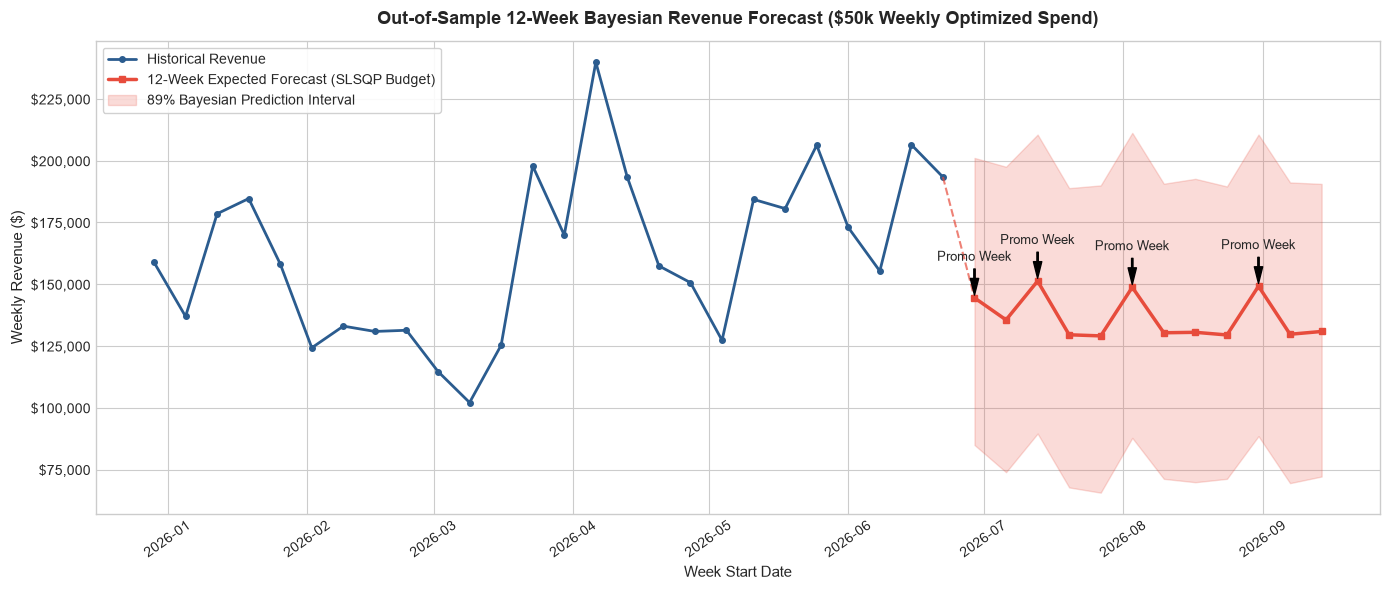

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

# 1. Plot Historical Revenue (Last 26 Weeks for Context)
hist_subset = df_hist.tail(26)
ax.plot(
    hist_subset['week_start'], 
    hist_subset['total_revenue'], 
    label="Historical Revenue", 
    color="#2b5c8f", 
    linewidth=2, 
    marker="o", 
    markersize=4
)

# Bridge the line between history and forecast
bridge_dates = [hist_subset['week_start'].iloc[-1], df_fcst['week_start'].iloc[0]]
bridge_values = [hist_subset['total_revenue'].iloc[-1], df_fcst['forecasted_revenue_mean'].iloc[0]]
ax.plot(bridge_dates, bridge_values, color="#e74c3c", linestyle="--", alpha=0.7)

# 2. Plot Out-of-Sample Mean Forecast
ax.plot(
    df_fcst['week_start'], 
    df_fcst['forecasted_revenue_mean'], 
    label="12-Week Expected Forecast (SLSQP Budget)", 
    color="#e74c3c", 
    linewidth=2.5, 
    marker="s", 
    markersize=5
)

# 3. Plot 89% Bayesian High Density Interval (HDI) Uncertainty Fan
ax.fill_between(
    df_fcst['week_start'],
    df_fcst['hdi_89_lower'],
    df_fcst['hdi_89_upper'],
    color="#e74c3c",
    alpha=0.20,
    label="89% Bayesian Prediction Interval"
)

# Annotate Promotional Spikes in Forecast
promo_weeks = df_fcst[df_fcst['forecasted_revenue_mean'] > 140000]
for _, row in promo_weeks.iterrows():
    ax.annotate(
        "Promo Week",
        xy=(row['week_start'], row['forecasted_revenue_mean']),
        xytext=(row['week_start'], row['forecasted_revenue_mean'] + 15000),
        arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
        fontsize=9,
        ha='center'
    )

# Formatting
ax.set_title("Out-of-Sample 12-Week Bayesian Revenue Forecast ($50k Weekly Optimized Spend)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Week Start Date", fontsize=11)
ax.set_ylabel("Weekly Revenue ($)", fontsize=11)
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()